# Demo

This demo walks through:
1. Making a layer/gate set for an IBM device.
2. Creating a 2-local Pauli-Lindblad model based on the device topology.
3. Build "vanilla" Pauli-Lindblad learning experiments.
4. Running the experiments.
5. Fitting the model and getting noise maps.

In [1]:
# This demo runs locally using AerExecutor with a fake backend, so no IBM
# credentials are required.
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider.backends.marrakesh import FakeMarrakesh

from qiskit_noise_learning.aer_executor import AerExecutor

backend = FakeMarrakesh()
aer_simulator = AerSimulator(method="stabilizer")

## 1. Build a gate set with a single layer on a ring of qubits

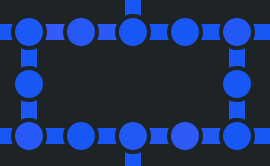

In [2]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [*range(25, 30), *range(37, 39), *range(45, 50)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26), (27, 28), (29, 38), (37, 45), (46, 47), (48, 49)]

with gate_set.build_new_gate("layer_1") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

In [3]:
gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [4]:
from qiskit_noise_learning.models import PauliLindbladModel

pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, k=2)

## 3. Build learning experiments

In [5]:
from qiskit_noise_learning.experiment_builder import (
    ExperimentBuilder,
    standard_vanilla_path_generator,
)

experiment_builder = ExperimentBuilder(fidelity_model=pauli_lindblad_model)

experiment_builder.add_paths(
    standard_vanilla_path_generator(
        experiment_builder.gate_set["P"],
        experiment_builder.gate_set["M"],
        experiment_builder.gate_set["layer_1"],
        pauli_lindblad_model.generators["layer_1"],
        experiment_builder.gate_set.coupling_map,
    ),
    attempt_instruction_merge=True,
)
experiment_builder.complete()

print(f"Number of paths: {len(experiment_builder.paths)}")
print(f"Number of instruction sequences: {len(experiment_builder.instruction_sequences)}")

Number of paths: 108
Number of instruction sequences: 9


## 4. Run experiments

In [6]:
# generate instruction sequences
depths = [0, 2, 16, 32, 64, 128]
instruction_sequences = experiment_builder.generate_instruction_sequences(depths)

print(f"Number of instruction sequences: {len(instruction_sequences)}")

Number of instruction sequences: 54


Number of template circuits: 6
Depth 2 template circuit:


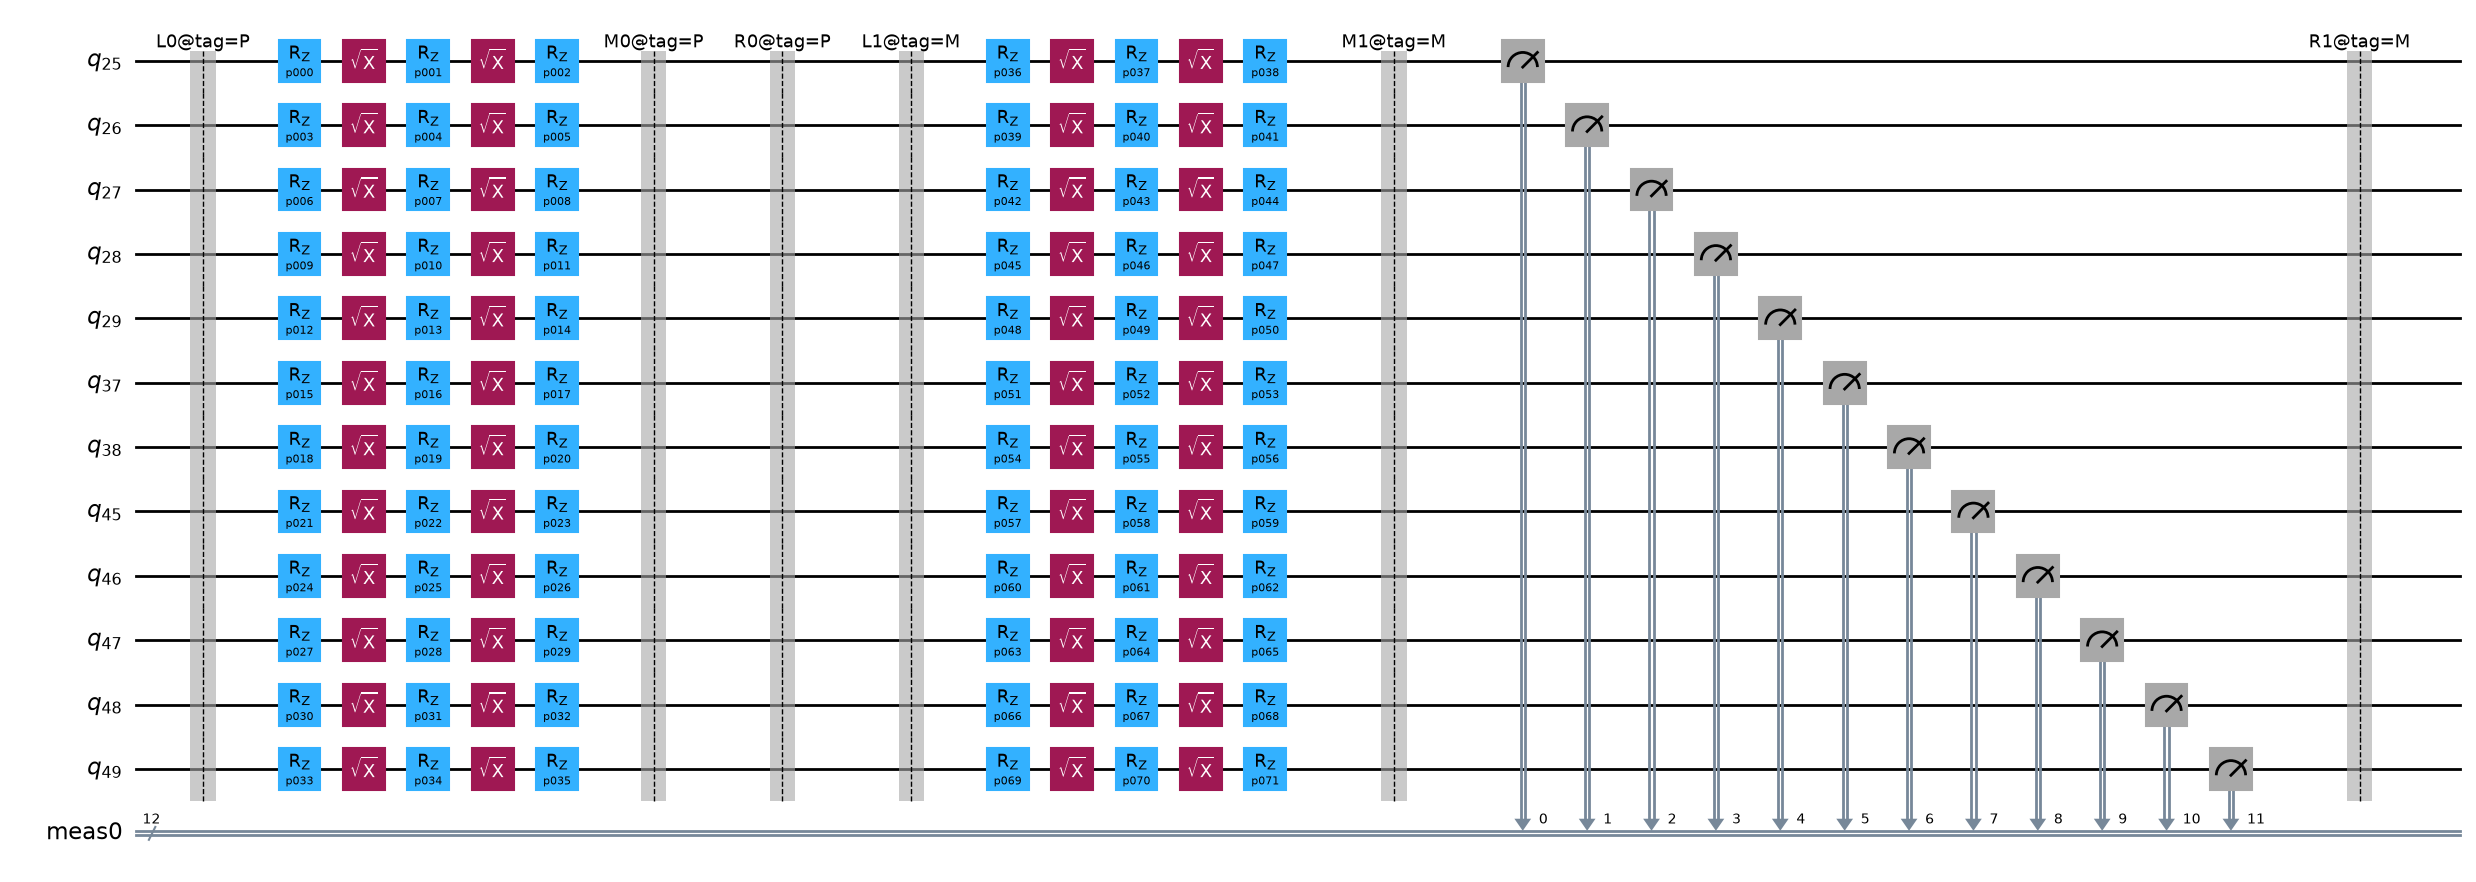

In [7]:
from qiskit.transpiler import PassManager

from qiskit_noise_learning.circuit_generator import ExecutorCircuitGenerator

# No post-selection passes are added here: the AerExecutor's stabilizer simulator
# can't natively execute the non-Clifford pulses inserted by `AddPostSelectionMeasures`.
# On a real runtime backend you would typically add `AddSpectatorMeasures` and
# `AddPostSelectionMeasures` here.
post_selection_pm = PassManager([])

# generate inputs to executor
num_rand = 50
circuit_generator = ExecutorCircuitGenerator(
    gate_set, num_randomizations=num_rand, pass_manager=post_selection_pm
)
samplex_items, data_mapper = circuit_generator.generate(instruction_sequences)

print(f"Number of template circuits: {len(samplex_items)}")
print("Depth 2 template circuit:")
samplex_items[0].circuit.draw("mpl", idle_wires=False, fold=False)

In [8]:
# Build a small simulated noise model on the layer_1 box. The map is in box-local
# qubit indices, so its `num_qubits` matches the box body's qubit count.
from qiskit.quantum_info import PauliLindbladMap
from qiskit_ibm_runtime import QuantumProgram

n_layer_qubits = len(qubit_subset)
local_idx = {phys: i for i, phys in enumerate(qubit_subset)}

layer_1_generators = []
layer_1_rates = []
for q0, q1 in layer_1_pairs:
    i0, i1 = local_idx[q0], local_idx[q1]
    for label in ("X", "Y", "Z"):
        chars = ["I"] * n_layer_qubits
        chars[i0] = label
        chars[i1] = label
        # Qiskit Pauli convention is little-endian (qubit 0 is rightmost).
        layer_1_generators.append("".join(reversed(chars)))
        layer_1_rates.append(0.005)

noise_dict = {
    "layer_1": PauliLindbladMap.from_list(list(zip(layer_1_generators, layer_1_rates))),
    # Empty maps short-circuit InsertNoisePass for tags we don't want noise on.
    "M": PauliLindbladMap.from_list([], num_qubits=n_layer_qubits),
    "P": PauliLindbladMap.from_list([], num_qubits=n_layer_qubits),
}

# Run program and collect raw data
num_shots = 64
executor = AerExecutor(qasm_simulator=aer_simulator, noise_dict=noise_dict)
qp = QuantumProgram(num_shots, samplex_items)
job = executor.run(qp)
raw_data = circuit_generator.collect(job.result(), data_mapper)

## 5. Analyzing the data

In [9]:
from qiskit_noise_learning.analysis import (
    ComputeObservables,
    CurveFitObservables,
    NNLSSolve,
)

# Note: `FlipPostSelect` is omitted because no post-selection cregs were generated.
analyzer = ComputeObservables() + CurveFitObservables() + NNLSSolve()

In [10]:
from qiskit_noise_learning.analysis import Fit
from qiskit_noise_learning.data import RawData

fit = Fit(
    model=pauli_lindblad_model,
    paths=[p.bind_at(d) for p in experiment_builder.paths for d in depths],
)
fit[RawData] = raw_data

In [11]:
fit = analyzer.run(fit)

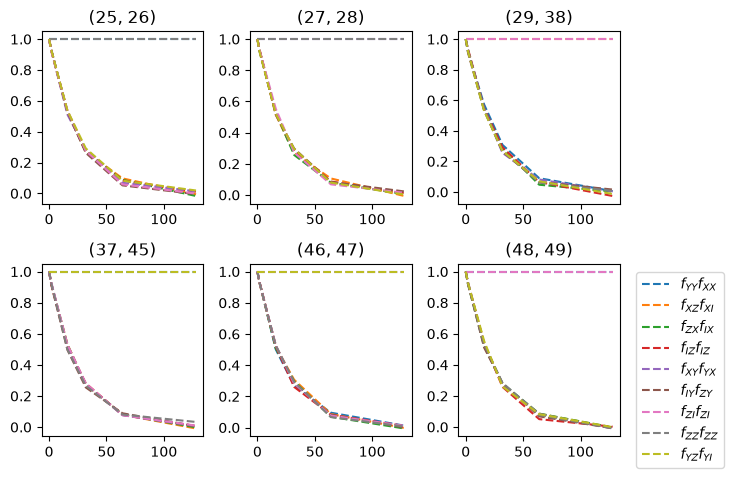

In [12]:
from matplotlib import pyplot as plt

from qiskit_noise_learning.analysis import AverageObservables

# compute observables and plot empirical decays

averaged_data = AverageObservables().run(fit).averaged_data


def _sorted_data(averaged_data):
    dataset = averaged_data.dataset

    sorted_data = {}
    for unbound_path, depth, val in zip(
        dataset["unbound_path"].data, dataset["depth"].data, dataset["observables"].data
    ):
        if depth < 0:
            continue
        this_data = sorted_data.setdefault(unbound_path, ([], []))
        this_data[0].append(val)
        this_data[1].append(depth)

    return {k: v for k, v in sorted_data.items() if len(v[0]) > 1}  # filter on decays


def plot(averaged_data, subsets, num_cols=3):
    sorted_data = _sorted_data(averaged_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for unbound_path in sorted_data.keys():
            if set(subset).issuperset(unbound_path.start_fragment[0].out_bit_indices):
                plots[subset].append(unbound_path)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, unbound_paths) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        for unbound_path in unbound_paths:
            this_data = sorted_data[unbound_path]
            label = fidelity_label(unbound_path, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                "--",
                label=label,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


def fidelity_label(unbound_path, subset):
    return (
        "$f_{"
        + "} f_{".join(
            "".join(str(fid.pauli.to_pauli()[subset])) for fid in unbound_path.repeatable_fragment
        )
        + "} $"
    )


plot(averaged_data, layer_1_pairs)

In [13]:
model_data = fit.model_data
noise_maps = pauli_lindblad_model.to_pauli_lindblad_maps(model_data)

### 5.1 Bootstrapping error bars on generator rates

The covariance computed in `NNLSSolve` is a linearized approximation. For a more rigorous
uncertainty estimate, we can bootstrap-resample randomizations and re-run the curve fit + NNLS
stages, then summarize the resulting distribution of generator rates.

Three resamplers are provided: `NumpyResampler` (naive, fast), `ScipyResampler` (delegates to
`scipy.stats.bootstrap`), and `ArchResampler` (uses `arch.bootstrap.IIDBootstrap`, requires
`pip install arch`).

In [14]:
from qiskit_noise_learning.analysis import (
    ArchResampler,
    Bootstrap,
    ComputeObservables,
    CurveFitObservables,
    NNLSSolve,
    NumpyResampler,  # noqa: F401  (kept for the swap-in suggestion below)
)

# Inner pipeline: from ObservableData to ModelData.
inner = CurveFitObservables() + NNLSSolve()

# Wrap it. Use NumpyResampler for a naive sanity check; swap in ArchResampler for the
# more rigorous variant.
bootstrap_stage = Bootstrap(
    inner,
    n_resamples=200,
    resampler=ArchResampler(seed=0),  # or NumpyResampler(seed=0)
    confidence_level=0.95,
)

bootstrap_analyzer = ComputeObservables() + bootstrap_stage

fit_bs = Fit(
    model=pauli_lindblad_model,
    paths=[p.bind_at(d) for p in experiment_builder.paths for d in depths],
)
fit_bs[RawData] = raw_data
fit_bs = bootstrap_analyzer.run(fit_bs)

bs_ds = fit_bs.model_data.dataset
print(f"resamples: {bs_ds.attrs['bootstrap_n_resamples']}")
print(f"resampler: {bs_ds.attrs['bootstrap_resampler']}")
print("first 5 generator rates with bootstrap 95% CI:")
for label, val, lo, hi in zip(
    bs_ds["parameter"].data[:5],
    bs_ds["parameter_values"].data[:5],
    bs_ds["bootstrap_ci_low"].data[:5],
    bs_ds["bootstrap_ci_high"].data[:5],
):
    print(f"  {label}: {val:.4f}  [{lo:.4f}, {hi:.4f}]")

resamples: 200
resampler: ArchResampler
first 5 generator rates with bootstrap 95% CI:
  GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Z_26>): 0.0000  [0.0000, 0.0002]
  GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Y_26>): 0.0000  [0.0000, 0.0005]
  GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Z_27>): 0.0000  [0.0000, 0.0002]
  GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: X_27>): 0.0000  [0.0000, 0.0003]
  GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Z_26 Z_25>): 0.0046  [0.0041, 0.0047]


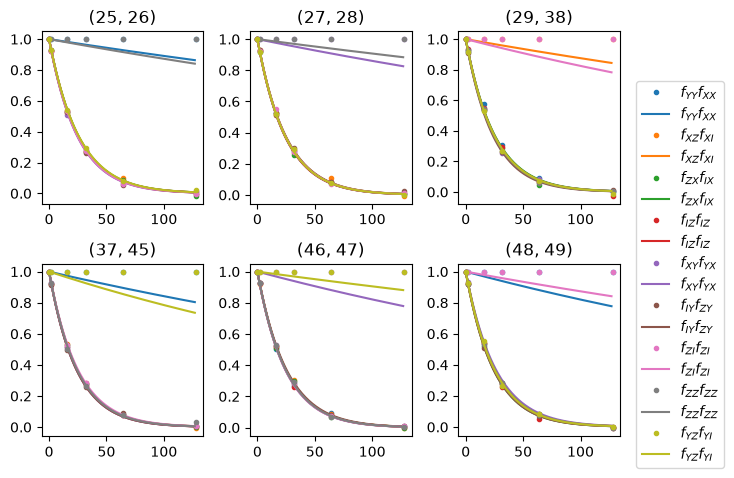

In [15]:
# plot decays v.s. model prediction
# Note: plotting model decays without prefactors from SPAM
import matplotlib.colors as mcolors
import numpy as np


def plot_with_model_decay(
    pauli_lindblad_map, observable_data, subsets, num_cols=3, start_idx=None, end_idx=None
):
    sorted_data = _sorted_data(observable_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for unbound_path in sorted_data.keys():
            if set(subset).issuperset(unbound_path.start_fragment[0].out_bit_indices):
                plots[subset].append(unbound_path)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, unbound_paths) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        if start_idx is None:
            start_idx = 0
        if end_idx is None:
            end_idx = len(unbound_paths)
        for color_code, unbound_path in list(zip(mcolors.TABLEAU_COLORS.values(), unbound_paths))[
            start_idx:end_idx
        ]:
            this_data = sorted_data[unbound_path]
            label = fidelity_label(unbound_path, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                ".",
                label=label,
                color=color_code,
            )
            pauli_in = unbound_path.repeatable_fragment[0].transition[0]
            fidelity_in = pauli_lindblad_map.pauli_fidelity(pauli_in)
            pauli_out = unbound_path.repeatable_fragment[0].transition[1]
            fidelity_out = pauli_lindblad_map.pauli_fidelity(pauli_out)
            ax.plot(
                np.arange(max(this_data[1])),
                (fidelity_in * fidelity_out) ** (np.arange(max(this_data[1]))),
                "-",
                label=label,
                color=color_code,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


# k = 8
plot_with_model_decay(
    noise_maps["layer_1"], averaged_data, layer_1_pairs
)  # , start_idx=k, end_idx=k + 1)